<a href="https://colab.research.google.com/github/isra-data-analytics/isra-data-analytics/blob/main/Taller_de_EDA_Apartamentos_Entrega2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import os
import pandas as pd
import requests

# 1. DEFINICIÓN DE ESTRUCTURA Y RUTAS
carpetas = ['input', 'source', 'output']
for folder in carpetas:
    os.makedirs(folder, exist_ok=True)
    print(f" Carpeta '{folder}' lista.")

# 2. DESCARGA AUTOMÁTICA DESDE GITHUB
# Usamos la URL 'raw' para obtener el archivo real, no la página web
base_url = "https://raw.githubusercontent.com/isra-data-analytics/isra-data-analytics/main/"

archivos = {
    "Variables Categoricas.xlsx": "input/Variables Categoricas.xlsx",
    "Variables Numericas.xlsx": "input/Variables Numericas.xlsx",
    "apartamentos_bogota (1).xlsx": "input/apartamentos_bogota (1).xlsx"
}

print("\n Descargando datasets desde GitHub...")
for nombre_web, ruta_local in archivos.items():
    # El nombre en la URL debe tener %20 en lugar de espacios
    url_final = base_url + nombre_web.replace(" ", "%20")
    response = requests.get(url_final)

    if response.status_code == 200:
        with open(ruta_local, 'wb') as f:
            f.write(response.content)
        print(f" {nombre_web} guardado en {ruta_local}")
    else:
        print(f" Error al descargar {nombre_web} (Status: {response.status_code})")

# 3. CARGA DE DATOS PARA TU MODELO
try:
    datos_CAT = pd.read_excel('input/Variables Categoricas.xlsx')
    print("\n DATOS CARGADOS: El modelo ya tiene la información vinculada.")
except Exception as e:
    print(f" Error al cargar los datos: {e}")

# Así el archivo caerá siempre en la carpeta que creamos
ruta_salida = os.path.join('output', 'tablas_frecuencia.xlsx')



 Carpeta 'input' lista.
 Carpeta 'source' lista.
 Carpeta 'output' lista.

 Descargando datasets desde GitHub...
 Variables Categoricas.xlsx guardado en input/Variables Categoricas.xlsx
 Variables Numericas.xlsx guardado en input/Variables Numericas.xlsx
 apartamentos_bogota (1).xlsx guardado en input/apartamentos_bogota (1).xlsx

 DATOS CARGADOS: El modelo ya tiene la información vinculada.


In [5]:
# =============================================================================
# LIBRERÍAS NECESARIAS
# =============================================================================

# Tratamiento de datos
# -----------------------------------------------------------------------------
import numpy as np          # Manejo de arrays y operaciones numéricas eficientes
import pandas as pd         # Manipulación y análisis de datos estructurados
from tabulate import tabulate   # Formateo de tablas para mejor visualización
from scipy import stats

# Gráficos
# -----------------------------------------------------------------------------
import matplotlib.pyplot as plt         # Librería base para visualizaciones
from matplotlib import style           # Estilos para gráficos
import matplotlib.ticker as ticker     # Formateo de ejes en gráficos
import seaborn as sns                 # Visualizaciones estadísticas avanzadas
import statsmodels.api as sm          # Modelos estadísticos y econométricos

# Configuración matplotlib
# -----------------------------------------------------------------------------
plt.rcParams['image.cmap'] = "bwr"    # Configura el mapa de colores predeterminado
plt.rcParams['savefig.bbox'] = "tight"  # Ajusta los márgenes al guardar figuras
style.use('ggplot') or plt.style.use('ggplot')  # Establece estilo visual ggplot

# Configuración warnings
# -----------------------------------------------------------------------------
import warnings
warnings.filterwarnings('ignore')  # Desactiva mensajes de advertencia
# pd.options.display.float_format = '{:.2f}'.format # Suprimir notación cientifica en python

In [6]:

pip install stats

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.6/127.6 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for stats: filename=stats-0.1.2a0-py3-none-any.whl size=24283 sha256=e4162cf8ed7df0cceca93864b4e09cdfc41c83735039c1246e1ca50ba5468244
  Stored in directory: /root/.cache/pip/wheels/cf/4f/48/be81fb2b5f67ca31d8bfe2e92a9ff516bd21a4824c85b19f5f
Successfully built stats


## Lectura de tablas

In [7]:
# 1. Cargar el dataset maestro (el que tiene todo)
dataset_maestro = pd.read_excel('input/apartamentos_bogota (1).xlsx')

# 2. Cargar selección de numéricas
df_num = pd.read_excel('input/Variables Numericas.xlsx')

# 3. Cargar selección de categóricas
df_cat = pd.read_excel('input/Variables Categoricas.xlsx')

In [8]:
df_cat.head()

,tipo_propiedad,localidad,sector,barrio,estrato,antiguedad,tipo_operacion
0,APARTAMENTO,SUBA,BRITALIA,URB. PICADELLY,3,ENTRE 10 Y 20 ANOS,VENTA
1,APARTAMENTO,USAQUEN,SAN CRISTOBAL NORTE,BARRANCAS PERLAS DEL NORTE,3,MAS DE 20 ANOS,VENTA
2,APARTAMENTO,LOS MARTIRES,LA SABANA,SAN VICTORINO,3,ENTRE 0 Y 5 ANOS,VENTA
3,APARTAMENTO,SUBA,TIBABUYES,LA ESTRELLA II,2,ENTRE 10 Y 20 ANOS,VENTA
4,APARTAMENTO,USAQUEN,VERBENAL,HORIZONTES USAQUEN,3,MAS DE 20 ANOS,VENTA


In [9]:
df_num.head()

,area,habitaciones,banos,parqueaderos,estrato
0,76.0,3,2,1,3
1,63.0,3,2,0,3
2,54.0,3,2,0,3
3,43.0,2,2,0,2
4,48.0,3,2,0,3


In [10]:

print("\n ENCABEZADOS: VARIABLES NUMÉRICAS")
display(df_num.head())

print("\n ENCABEZADOS: VARIABLES CATEGÓRICAS")
display(df_cat.head())


 ENCABEZADOS: VARIABLES NUMÉRICAS


,area,habitaciones,banos,parqueaderos,estrato
0,76.0,3,2,1,3
1,63.0,3,2,0,3
2,54.0,3,2,0,3
3,43.0,2,2,0,2
4,48.0,3,2,0,3



 ENCABEZADOS: VARIABLES CATEGÓRICAS


,tipo_propiedad,localidad,sector,barrio,estrato,antiguedad,tipo_operacion
0,APARTAMENTO,SUBA,BRITALIA,URB. PICADELLY,3,ENTRE 10 Y 20 ANOS,VENTA
1,APARTAMENTO,USAQUEN,SAN CRISTOBAL NORTE,BARRANCAS PERLAS DEL NORTE,3,MAS DE 20 ANOS,VENTA
2,APARTAMENTO,LOS MARTIRES,LA SABANA,SAN VICTORINO,3,ENTRE 0 Y 5 ANOS,VENTA
3,APARTAMENTO,SUBA,TIBABUYES,LA ESTRELLA II,2,ENTRE 10 Y 20 ANOS,VENTA
4,APARTAMENTO,USAQUEN,VERBENAL,HORIZONTES USAQUEN,3,MAS DE 20 ANOS,VENTA


In [11]:
# Combinar los DataFrames
df = pd.concat([df_num, df_cat], axis=1)
df.head()

,area,habitaciones,banos,parqueaderos,estrato,tipo_propiedad,localidad,sector,barrio,estrato,antiguedad,tipo_operacion
0,76.0,3,2,1,3,APARTAMENTO,SUBA,BRITALIA,URB. PICADELLY,3,ENTRE 10 Y 20 ANOS,VENTA
1,63.0,3,2,0,3,APARTAMENTO,USAQUEN,SAN CRISTOBAL NORTE,BARRANCAS PERLAS DEL NORTE,3,MAS DE 20 ANOS,VENTA
2,54.0,3,2,0,3,APARTAMENTO,LOS MARTIRES,LA SABANA,SAN VICTORINO,3,ENTRE 0 Y 5 ANOS,VENTA
3,43.0,2,2,0,2,APARTAMENTO,SUBA,TIBABUYES,LA ESTRELLA II,2,ENTRE 10 Y 20 ANOS,VENTA
4,48.0,3,2,0,3,APARTAMENTO,USAQUEN,VERBENAL,HORIZONTES USAQUEN,3,MAS DE 20 ANOS,VENTA


In [12]:
print(df_num.shape)
print(df_cat.shape)

(43013, 5)
(43013, 7)


## Entendimiento de los Datos


In [13]:
# Estructura y Tipos de Datos
dataset_maestro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43013 entries, 0 to 43012
Data columns (total 46 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   _id                      43013 non-null  object        
 1   codigo                   43013 non-null  object        
 2   tipo_propiedad           43013 non-null  object        
 3   tipo_operacion           43013 non-null  object        
 4   precio_venta             27584 non-null  float64       
 5   area                     43013 non-null  float64       
 6   habitaciones             43013 non-null  object        
 7   banos                    43013 non-null  object        
 8   administracion           43013 non-null  object        
 9   parqueaderos             43013 non-null  object        
 10  sector                   43013 non-null  object        
 11  estrato                  43013 non-null  object        
 12  antiguedad               43013 n

In [14]:
print(f"El dataset tiene {dataset_maestro.shape[0]} registros y {dataset_maestro.shape[1]} columnas.")

El dataset tiene 43013 registros y 46 columnas.


In [15]:
#ME MUESTRA LOS NOMBRES DE LAS VARIABLES Y EL TIPO (int64, float64 u object)

print(dataset_maestro.dtypes)

_id                                object
codigo                             object
tipo_propiedad                     object
tipo_operacion                     object
precio_venta                      float64
area                              float64
habitaciones                       object
banos                              object
administracion                     object
parqueaderos                       object
sector                             object
estrato                            object
antiguedad                         object
latitud                           float64
longitud                          float64
direccion                          object
descripcion                        object
website                            object
last_view                          object
datetime                   datetime64[ns]
url                                object
timeline                           object
estado                             object
compañia                          

In [16]:
print(dataset_maestro.dtypes.value_counts())

object            35
float64            7
int64              2
datetime64[ns]     1
bool               1
Name: count, dtype: int64


In [17]:
#Análisis de Valores Nulos

# Cálculo de nulos y su porcentaje
nulos = dataset_maestro.isnull().sum()
porcentaje_nulos = (nulos / len(dataset_maestro)) * 100

# Tabla de diagnóstico
tabla_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': porcentaje_nulos.round(2)})
display(tabla_nulos[tabla_nulos['Nulos'] > 0].sort_values(by='Nulos', ascending=False))

,Nulos,Porcentaje (%)
precio_arriendo,27184,63.20
precio_venta,15429,35.87
datetime,2,0.00


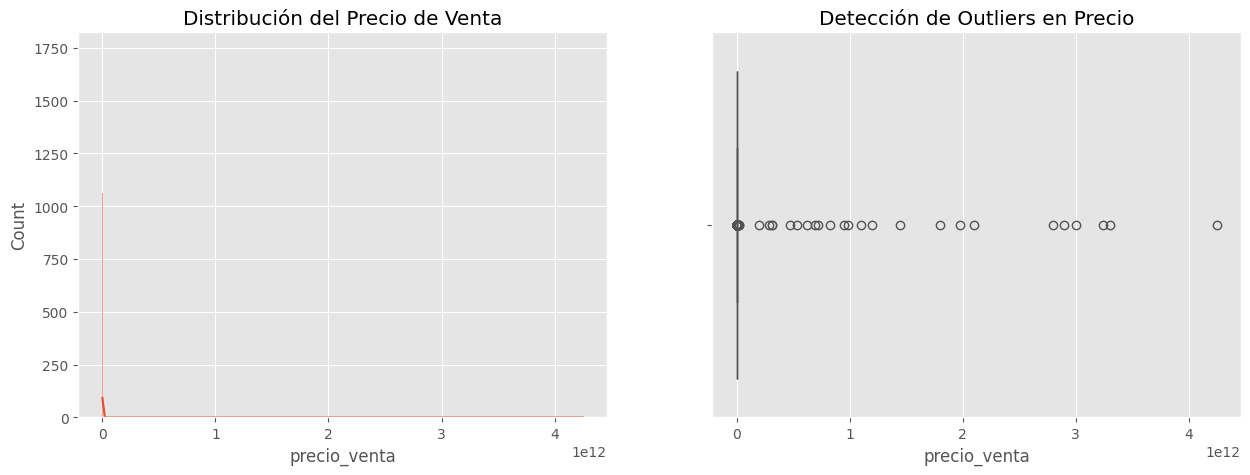

In [18]:
#Distribución del Precio y Outliers


# Histograma y Boxplot
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(dataset_maestro['precio_venta'], kde=True, ax=ax[0])
ax[0].set_title('Distribución del Precio de Venta')

sns.boxplot(x=dataset_maestro['precio_venta'], ax=ax[1])
ax[1].set_title('Detección de Outliers en Precio')

plt.show()

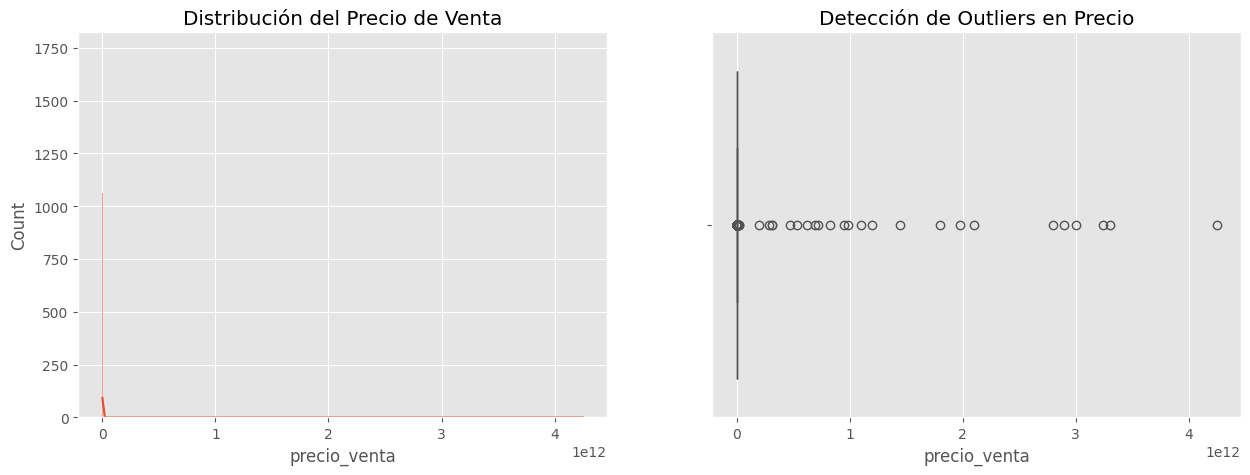

In [19]:
# Distribución del Precio y Outliers

# Histograma y Boxplot
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(dataset_maestro['precio_venta'], kde=True, ax=ax[0])
ax[0].set_title('Distribución del Precio de Venta')

sns.boxplot(x=dataset_maestro['precio_venta'], ax=ax[1])
ax[1].set_title('Detección de Outliers en Precio')

plt.show()

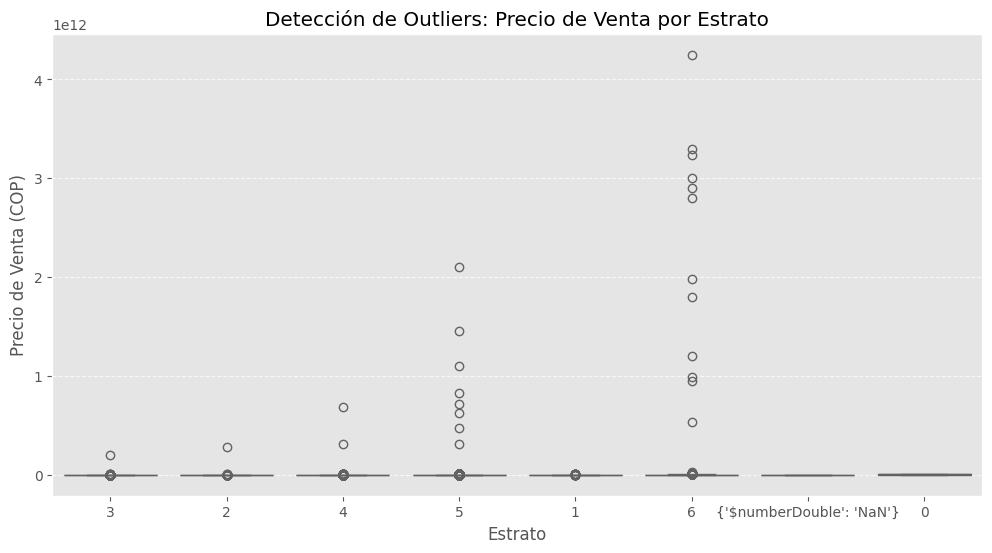

In [20]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='estrato', y='precio_venta', data=dataset_maestro, palette='Set3')
plt.title('Detección de Outliers: Precio de Venta por Estrato')
plt.xlabel('Estrato')
plt.ylabel('Precio de Venta (COP)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

La escala del eje Y:
Arriba dice 1e12. Eso significa que tenemos apartamentos con precios de billones de pesos (ej. $4 \times 10^{12}$ sería 4 billones). Estos datos son errores de carga o ruido.Cajas "aplastadas": Las cajas de los estratos no se ven porque la escala está distorsionada por esos puntos de arriba.
Datos sucios en el eje X: Tenemos una categoría llamada NaN y otra 0. Los apartamentos de estrato 0 no existen en el esquema urbano normal de Bogotá (o son casos muy especiales).

In [21]:
#  filtra outliers en precio_venta
Q1 = dataset_maestro['precio_venta'].quantile(0.25)
Q3 = dataset_maestro['precio_venta'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Dataset sin outliers extremos
df_sin_outliers = dataset_maestro[(dataset_maestro['precio_venta'] >= limite_inferior) &
                                 (dataset_maestro['precio_venta'] <= limite_superior)]

print(f"Registros originales: {len(dataset_maestro)}")
print(f"Registros tras filtrar outliers: {len(df_sin_outliers)}")

Registros originales: 43013
Registros tras filtrar outliers: 25639


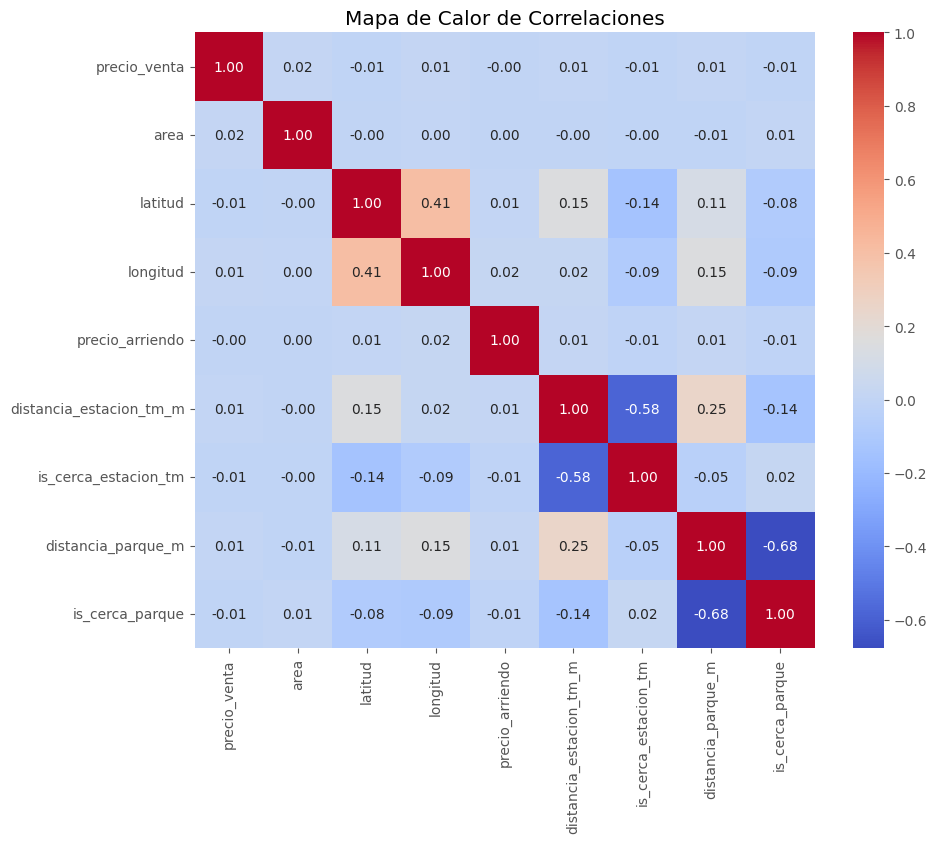

In [22]:
# Relaciones y Correlaciones

# Matriz de correlación
plt.figure(figsize=(10, 8))
# Seleccionamos solo las numéricas para la matriz
corr = dataset_maestro.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor de Correlaciones')
plt.show()

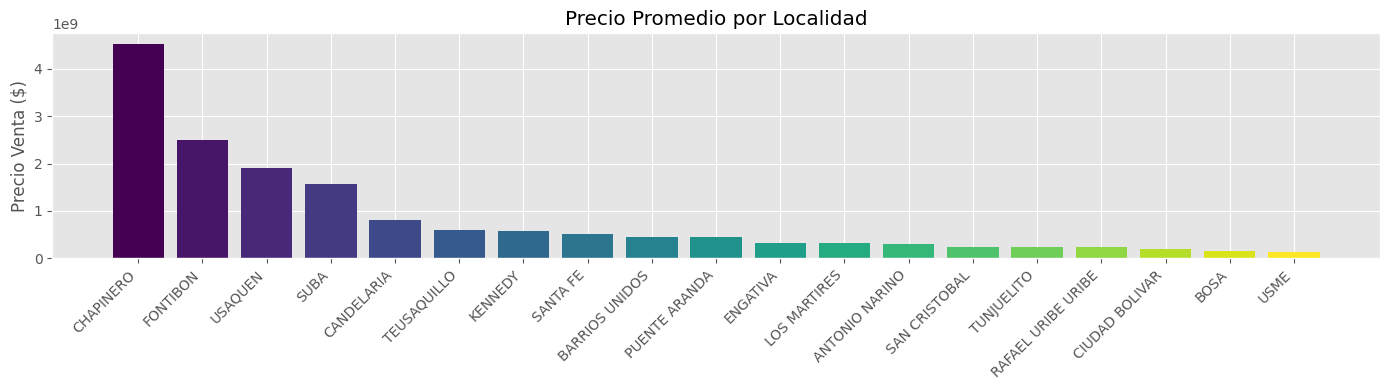

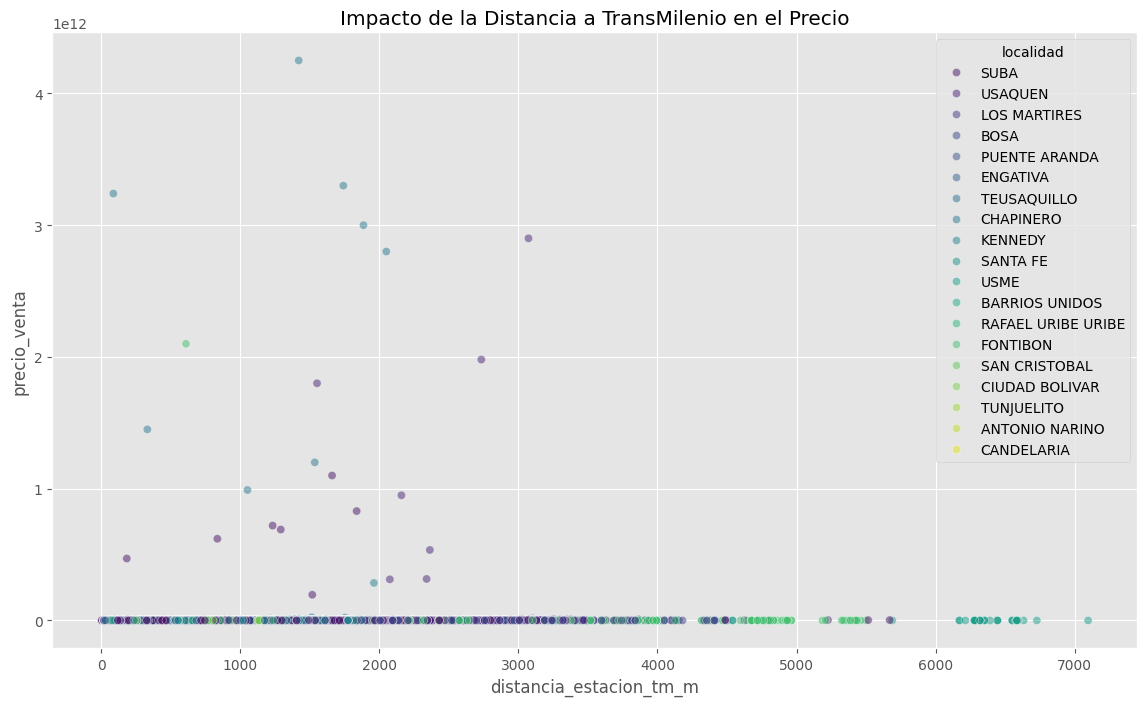

In [23]:
# Localidad y Factores Externos (Parques/TransMilenio)

# Precio promedio por localidad
plt.figure(figsize=(14, 4))
data = dataset_maestro.groupby('localidad')['precio_venta'].mean().sort_values(ascending=False)
colors = plt.cm.viridis(np.linspace(0, 1, len(data))) # Generar colores diferentes para cada barra

# Crear gráfico de barras
plt.bar(data.index, data.values, color=colors)

plt.title('Precio Promedio por Localidad')
plt.ylabel('Precio Venta ($)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


# Relación Distancia vs Precio
plt.figure(figsize=(14, 8))
scatter = sns.scatterplot(data=dataset_maestro, x='distancia_estacion_tm_m', y='precio_venta',
                          alpha=0.5, hue=dataset_maestro['localidad'],
                          palette='viridis', legend='full')


plt.title('Impacto de la Distancia a TransMilenio en el Precio')
plt.show()


In [24]:
# Criterio de "Cerca" o "Lejos"

# Definición estadística de cercanía
distancias = dataset_maestro[['distancia_parque_m', 'distancia_estacion_tm_m']].describe()
display(distancias)

,distancia_parque_m,distancia_estacion_tm_m
count,43013.000000,43013.000000
mean,808.884766,1270.515946
std,447.796211,841.814012
min,0.220000,4.940000
25%,470.140000,578.380000
50%,750.140000,1175.520000
75%,1087.730000,1707.920000
max,6276.510000,7095.660000


In [25]:
# Limpiar y convertir la columna de administración a numérica (sin eliminar datos originales)
dataset_maestro['administracion_limpia'] = pd.to_numeric(dataset_maestro['administracion'], errors='coerce')

# Calcular correlación solo con los valores válidos (ignorando NaNs automáticamente)
correlacion_admin = dataset_maestro['precio_venta'].corr(dataset_maestro['administracion_limpia'])
print(f"La correlación entre Precio y Administración es de: {correlacion_admin:.2f}")

# Mostrar cuántos valores se usaron
valores_validos = dataset_maestro['administracion_limpia'].notna().sum()
print(f"Valores válidos considerados: {valores_validos} de {len(dataset_maestro)} totales")

La correlación entre Precio y Administración es de: 0.03
Valores válidos considerados: 35088 de 43013 totales


--- ANÁLISIS DE FALTANTES (DATASET MAESTRO) ---
                       Faltantes (Total)  Porcentaje (%)
precio_arriendo                    27184       63.199498
precio_venta                       15429       35.870551
administracion_limpia               7925       18.424662
datetime                               2        0.004650


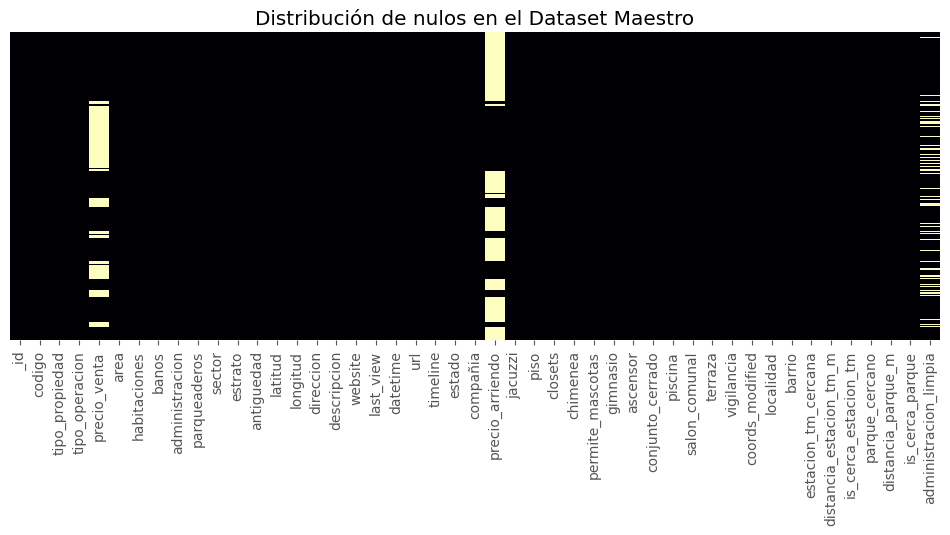

In [26]:
# 1. Identificación detallada en el Dataset Maestro
print("--- ANÁLISIS DE FALTANTES (DATASET MAESTRO) ---")
nulos_conteo = dataset_maestro.isnull().sum()
nulos_porcentaje = (dataset_maestro.isnull().sum() / len(dataset_maestro)) * 100

# Creamos un resumen para verlo más claro
resumen_nulos = pd.DataFrame({
    'Faltantes (Total)': nulos_conteo,
    'Porcentaje (%)': nulos_porcentaje
})

# Solo mostramos las columnas que tienen al menos un nulo
print(resumen_nulos[resumen_nulos['Faltantes (Total)'] > 0].sort_values(by='Porcentaje (%)', ascending=False))

# 2. Visualización rápida para ver patrones
plt.figure(figsize=(12, 4))
sns.heatmap(dataset_maestro.isnull(), yticklabels=False, cbar=False, cmap='magma')
plt.title('Distribución de nulos en el Dataset Maestro')
plt.show()

## Preparación de los Datos

##Imputación de Nulos:
Rellenamos los espacios vacíos donde falta información de acuerdo a la mediana por estrato

##Limpieza de Outliers (Filtrado):
Eliminamos los "datos mentirosos" o extremos. El Rango Intercuartílico nos ayuda a definir un "límite de normalidad".

##Ingeniería de Características (Feature Engineering):
Creamos "nuevas-variables" a partir de las que ya tenemos.

##Codificación (Encoding):
One-Hot Encoding: Creamos columnas de ceros y unos para cada categoría. Por ejemplo: una columna llamada Localidad_Suba que tendrá un 1 si el apto está ahí y un 0 si no.

##Escalado:
StandardScaler o MinMaxScaler: El modelo trata a todas las variables con la misma importancia matemática.

```
# Esto tiene formato de código
```



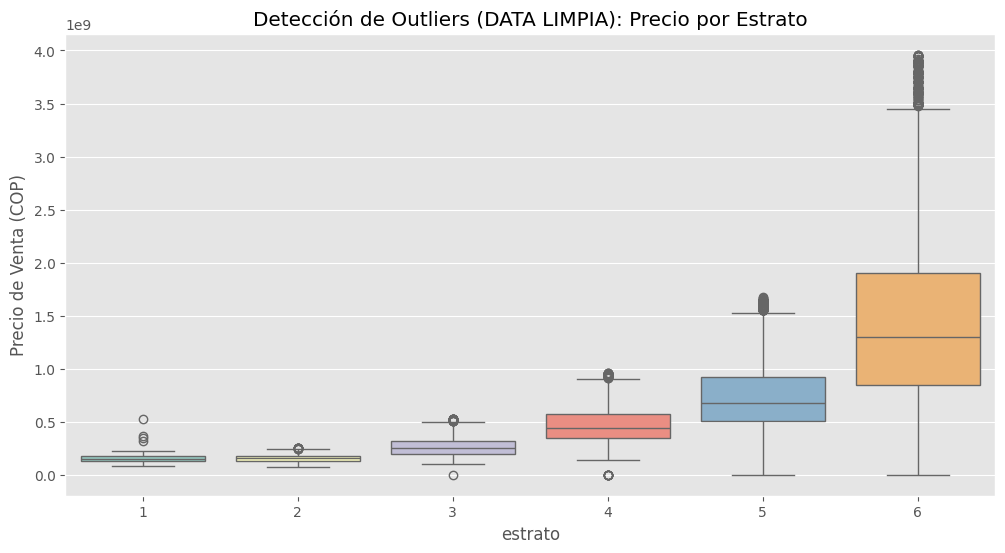

Registros eliminados (ruido/extremos): 17001


In [27]:
#Limpieza de Outliers (Filtrado):
def limpiar_outliers_por_estrato(df, columna_precio, columna_estrato):
    df_limpio = pd.DataFrame()

    # Solo iteramos sobre estratos válidos (1 al 6)
    estratos_validos = [1, 2, 3, 4, 5, 6]

    for estrato in estratos_validos:
        # Filtramos los datos del estrato actual
        subset = df[df[columna_estrato] == estrato]

        if not subset.empty:
            Q1 = subset[columna_precio].quantile(0.25)
            Q3 = subset[columna_precio].quantile(0.75)
            IQR = Q3 - Q1

            # Definimos límites
            limite_inferior = Q1 - 1.5 * IQR
            limite_superior = Q3 + 1.5 * IQR

            # Filtramos
            subset_filtrado = subset[(subset[columna_precio] >= limite_inferior) &
                                     (subset[columna_precio] <= limite_superior)]

            df_limpio = pd.concat([df_limpio, subset_filtrado])

    return df_limpio

# Aplicamos la limpieza
dataset_final = limpiar_outliers_por_estrato(dataset_maestro, 'precio_venta', 'estrato')

# Graficamos para ver la diferencia
plt.figure(figsize=(12, 6))
sns.boxplot(x='estrato', y='precio_venta', data=dataset_final, palette='Set3')
plt.title('Detección de Outliers (DATA LIMPIA): Precio por Estrato')
plt.ylabel('Precio de Venta (COP)')
plt.show()

print(f"Registros eliminados (ruido/extremos): {len(dataset_maestro) - len(dataset_final)}")

In [28]:
# 1. Identificar los registros que NO están en el dataset final
eliminados = dataset_maestro[~dataset_maestro.index.isin(dataset_final.index)]

# 2. Ver un resumen de esos datos "rebeldes"
print(f"Se eliminaron {len(eliminados)} registros.")
print("\n--- MUESTRA DE DATOS ELIMINADOS ---")
display(eliminados[['precio_venta', 'area', 'estrato', 'localidad']].head(10))

# 3. Estadísticos de los eliminados para entender por qué se fueron
print("\n--- RESUMEN DE PRECIOS ELIMINADOS ---")
print(eliminados['precio_venta'].describe())

Se eliminaron 17001 registros.

--- MUESTRA DE DATOS ELIMINADOS ---


,precio_venta,area,estrato,localidad
16,4.900000e+08,126.00,2,BOSA
132,2.737778e+08,41.00,2,LOS MARTIRES
242,2.809000e+08,71.00,2,KENNEDY
391,4.700000e+08,69.00,{'$numberDouble': 'NaN'},CHAPINERO
482,1.980000e+09,215.00,5,TEUSAQUILLO
549,1.850000e+09,300.00,3,USAQUEN
587,4.200000e+08,77.00,2,CANDELARIA
626,1.400000e+09,126.00,4,FONTIBON
633,2.100000e+09,250.00,5,CHAPINERO
641,5.910000e+08,69.58,2,CANDELARIA



--- RESUMEN DE PRECIOS ELIMINADOS ---
count    1.572000e+03
mean     2.622564e+10
std      2.322517e+11
min      2.600000e+08
25%      1.450000e+09
50%      3.050000e+09
75%      4.800000e+09
max      4.250000e+12
Name: precio_venta, dtype: float64


In [29]:
# Verificamos si quedan nulos en el dataset que ya está sin outliers
print("Nulos restantes después de limpiar outliers:")
print(dataset_final.isnull().sum()[dataset_final.isnull().sum() > 0])

Nulos restantes después de limpiar outliers:
datetime                     2
precio_arriendo          25659
administracion_limpia     2223
dtype: int64


In [30]:
#Imputación de Nulos
# 1. Eliminamos la columna de arriendo (demasiados nulos)
if 'precio_arriendo' in dataset_final.columns:
    dataset_final.drop(columns=['precio_arriendo'], inplace=True)
    print("- Columna 'precio_arriendo' eliminada.")

# 2. Imputamos 'administracion_limpia' con la MEDIANA POR ESTRATO
# Usamos transform para que cada nulo se llene con la mediana de SU propio estrato
dataset_final['administracion_limpia'] = dataset_final.groupby('estrato')['administracion_limpia'].transform(lambda x: x.fillna(x.median()))
print("- Administración imputada por estrato.")

# 3. Imputamos 'datetime' con la moda (el valor más común)
if 'datetime' in dataset_final.columns:
    dataset_final['datetime'] = dataset_final['datetime'].fillna(dataset_final['datetime'].mode()[0])
    print("- Fechas faltantes corregidas.")

# VERIFICACIÓN FINAL
print("\n--- ESTADO FINAL DE NULOS ---")
print(dataset_final[['administracion_limpia', 'datetime']].isnull().sum())

- Columna 'precio_arriendo' eliminada.
- Administración imputada por estrato.
- Fechas faltantes corregidas.

--- ESTADO FINAL DE NULOS ---
administracion_limpia    0
datetime                 0
dtype: int64


In [31]:
#Ingeniería de Características (Feature Engineering):

# Forzamos la conversión a numérico de las columnas implicadas - Dado que arrojaba error cuando intetnte convertitr en numero las variables.
cols_numericas = ['precio_venta', 'area', 'habitaciones', 'banos']

for col in cols_numericas:
    dataset_final[col] = pd.to_numeric(dataset_final[col], errors='coerce')

# Eliminamos posibles nulos que hayan surgido de la conversión (registros con texto basura)
dataset_final = dataset_final.dropna(subset=cols_numericas)

In [32]:

# --- 1. CURACIÓN DE TIPOS (Evita el TypeError) ---
# Forzamos a que las columnas clave sean numéricas, eliminando basura visual ($ o puntos)
cols_numericas = ['precio_venta', 'area', 'banos', 'habitaciones', 'estrato']

for col in cols_numericas:
    if col in dataset_final.columns:
        # Convertimos a string, quitamos símbolos no numéricos y pasamos a float
        dataset_final[col] = pd.to_numeric(
            dataset_final[col].astype(str).str.replace(r'[^\d.]', '', regex=True),
            errors='coerce'
        )

# --- 2. INGENIERÍA DE CARACTERÍSTICAS (Feature Engineering) ---
print("Calculando nuevas métricas...")

# Precio por Metro Cuadrado (Métrica de valor real)
dataset_final['precio_m2'] = dataset_final['precio_venta'] / dataset_final['area']

# Ratio Baños/Habitaciones (Indicador de nivel de lujo/confort)
# Sumamos 0.1 al denominador para evitar divisiones por cero (infinitos)
dataset_final['ratio_banos_hab'] = dataset_final['banos'] / (dataset_final['habitaciones'] + 0.1)

# --- 3. VALIDACIÓN POR LOCALIDAD ---
resumen_localidad = dataset_final.groupby('localidad')[['precio_m2', 'precio_venta']].median().sort_values(by='precio_m2', ascending=False)

print("\n--- TOP 5 LOCALIDADES POR PRECIO M2 (MEDIANA) ---")
display(resumen_localidad.head())

# Verificamos que no queden nulos tras la conversión
print(f"\nNulos generados por error de conversión: {dataset_final['precio_m2'].isna().sum()}")

Calculando nuevas métricas...

--- TOP 5 LOCALIDADES POR PRECIO M2 (MEDIANA) ---


,precio_m2,precio_venta
localidad,,
CHAPINERO,8.207926e+06,1.304000e+09
SANTA FE,7.961265e+06,4.000000e+08
TEUSAQUILLO,6.913480e+06,5.274000e+08
USAQUEN,6.359825e+06,7.500000e+08
BARRIOS UNIDOS,6.250000e+06,4.050000e+08



Nulos generados por error de conversión: 0


In [33]:
# 1. Aplicamos One-Hot Encoding a las variables categóricas principales
# Normalmente se hace con 'localidad', ya que 'barrio' puede generar cientos de columnas
dataset_preparado = pd.get_dummies(dataset_final, columns=['localidad'], drop_first=True)

# 2. Verificamos cómo quedó el dataset
print("--- NUEVAS COLUMNAS DE LOCALIDAD ---")
columnas_localidad = [col for col in dataset_preparado.columns if 'localidad_' in col]
print(f"Se crearon {len(columnas_localidad)} columnas nuevas para las localidades.")

# 3. Limpieza de columnas no numéricas para el modelo
# Eliminamos columnas de texto que no sirven para el cálculo matemático directo
cols_a_eliminar = ['_id', 'codigo', 'tipo_propiedad', 'tipo_operacion', 'barrio', 'datetime', 'descripcion', 'url']
dataset_modelo = dataset_preparado.drop(columns=[c for c in cols_a_eliminar if c in dataset_preparado.columns])

print("\n--- ESTRUCTURA FINAL DEL DATASET PARA EL MODELO ---")
display(dataset_modelo.head())

--- NUEVAS COLUMNAS DE LOCALIDAD ---
Se crearon 18 columnas nuevas para las localidades.

--- ESTRUCTURA FINAL DEL DATASET PARA EL MODELO ---


,precio_venta,area,habitaciones,banos,administracion,parqueaderos,sector,estrato,antiguedad,latitud,...,localidad_LOS MARTIRES,localidad_PUENTE ARANDA,localidad_RAFAEL URIBE URIBE,localidad_SAN CRISTOBAL,localidad_SANTA FE,localidad_SUBA,localidad_TEUSAQUILLO,localidad_TUNJUELITO,localidad_USAQUEN,localidad_USME
41,170500000.0,57.0,3.0,1.0,150000,0,LAS MARGARITAS,1,ENTRE 5 Y 10 ANOS,4.634299,...,False,False,False,False,False,False,False,False,False,False
122,155900000.0,57.0,3.0,1.0,150000,0,LAS MARGARITAS,1,ENTRE 5 Y 10 ANOS,4.633285,...,False,False,False,False,False,False,False,False,False,False
128,130804645.0,43.0,3.0,1.0,60000,0,EL PORVENIR,1,ENTRE 0 Y 5 ANOS,4.637406,...,False,False,False,False,False,False,False,False,False,False
159,140161187.0,44.0,3.0,1.0,58300,0,TINTAL SUR,1,ENTRE 5 Y 10 ANOS,4.621051,...,False,False,False,False,False,False,False,False,False,False
197,180504351.0,57.0,3.0,1.0,54500,0,PATIO BONITO,1,ENTRE 5 Y 10 ANOS,4.642987,...,False,False,False,False,False,False,False,False,False,False


In [34]:
# 1. ¿Cuántos datos tenemos originalmente?
total_inicial = len(dataset_modelo)

# 2. ¿Cuántos nulos hay por columna?
nulos_por_columna = dataset_modelo.isnull().sum()

# 3. ¿Cuántas filas quedarían después del dropna?
total_final = len(dataset_modelo.dropna())

print(f"Registros iniciales: {total_inicial}")
print(f"Registros tras limpieza: {total_final}")
print(f"Pérdida total: {total_inicial - total_final} filas ({((total_inicial - total_final)/total_inicial)*100:.2f}%)")
print("\nNulos que están causando la pérdida:")
print(nulos_por_columna[nulos_por_columna > 0])

Registros iniciales: 26011
Registros tras limpieza: 26011
Pérdida total: 0 filas (0.00%)

Nulos que están causando la pérdida:
Series([], dtype: int64)


In [35]:
print(f"Actualmente tenemos {len(dataset_modelo)} registros en el dataset.")

Actualmente tenemos 26011 registros en el dataset.


In [36]:
dataset_modelo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26011 entries, 41 to 43011
Data columns (total 57 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   precio_venta                  26011 non-null  float64
 1   area                          26011 non-null  float64
 2   habitaciones                  26011 non-null  float64
 3   banos                         26011 non-null  float64
 4   administracion                26011 non-null  object 
 5   parqueaderos                  26011 non-null  object 
 6   sector                        26011 non-null  object 
 7   estrato                       26011 non-null  int64  
 8   antiguedad                    26011 non-null  object 
 9   latitud                       26011 non-null  float64
 10  longitud                      26011 non-null  float64
 11  direccion                     26011 non-null  object 
 12  website                       26011 non-null  object 
 13  last_

## DATOS DESCARTADOS:
Outliers Extremos (El "Ruido"): Eliminamos precios de $10^{12}$ (un billón de pesos) que son errores de digitación. Si dejamos un solo apartamento de 1 billón en un estrato 3, el promedio se dispara y el modelo intentará predecir precios absurdos para todos.
Filtro por Estrato (IQR): Al limpiar por cada estrato, eliminamos los "falsos positivos". Por ejemplo, un apartamento en estrato 6 que supuestamente cuesta 20 millones (error) o uno de estrato 2 que cuesta 5,000 millones.
Registros Incompletos (NaN): Eliminamos los que no tenían area o precio_venta. Un algoritmo de regresión no puede "adivinar" el precio si no tiene los metros cuadrados; dejar esas filas vacías solo rompería el código.
Estratos 0 o Inválidos: En Bogotá, el estrato 0 no es comercialmente estándar para vivienda, y los NaN en estrato impiden segmentar correctamente el mercado.

In [37]:
# 1. Conteo de registros por estrato en el dataset final
distribucion_estratos = dataset_modelo['estrato'].value_counts().sort_index()

# 2. Porcentaje que representa cada uno
porcentaje_estratos = (dataset_modelo['estrato'].value_counts(normalize=True) * 100).sort_index()

# 3. Creamos un resumen visual
resumen_limpieza = pd.DataFrame({
    'Cantidad_Registros': distribucion_estratos,
    'Participacion_%': porcentaje_estratos.round(2)
})

print("--- ANÁLISIS DE REPRESENTATIVIDAD POR ESTRATO ---")
display(resumen_limpieza)

# 4. Validación de Precios Medios para ver coherencia
print("\n--- PRECIO MEDIO POR ESTRATO (Validación de lógica de mercado) ---")
print(dataset_final.groupby('estrato')['precio_venta'].median().apply(lambda x: f"${x:,.0f}"))

--- ANÁLISIS DE REPRESENTATIVIDAD POR ESTRATO ---


,Cantidad_Registros,Participacion_%
estrato,,
1,61,0.23
2,897,3.45
3,3253,12.51
4,5487,21.09
5,4986,19.17
6,11327,43.55



--- PRECIO MEDIO POR ESTRATO (Validación de lógica de mercado) ---
estrato
1      $145,000,000
2      $158,000,000
3      $250,000,000
4      $445,000,000
5      $680,000,000
6    $1,300,000,000
Name: precio_venta, dtype: object


In [38]:
from sklearn.model_selection import train_test_split

# Definimos variables predictoras (X) y objetivo (y)
X = dataset_modelo.drop(columns=['precio_venta'])
y = dataset_modelo['precio_venta']

# División siguiendo la recomendación de la guía (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print(f"  División completada:")
print(f"- Entrenamiento (80%): {X_train.shape[0]} registros")
print(f"- Prueba (20%): {X_test.shape[0]} registros")

  División completada:
- Entrenamiento (80%): 20808 registros
- Prueba (20%): 5203 registros


In [39]:
# 1. Convertir a numérico forzando errores a NaN
# Esto convertirá 'COUNTRY' y cualquier otro texto en un valor nulo (NaN) automáticamente
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

# 2. Ahora sí, eliminamos las columnas que quedaron totalmente vacías
# (por si 'COUNTRY' era toda una columna de texto)
X_train = X_train.dropna(axis=1, how='all')
X_test = X_test[X_train.columns] # Aseguramos que test tenga las mismas columnas que train

# 3. Eliminamos filas con NaN restantes (los que antes eran 'COUNTRY' o basura)
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]

print(f"✅ Limpieza profunda completada.")
print(f"Registros finales para entrenamiento: {X_train.shape[0]}")
print(f"Columnas finales (todas numéricas): {X_train.shape[1]}")

✅ Limpieza profunda completada.
Registros finales para entrenamiento: 19064
Columnas finales (todas numéricas): 44


In [40]:
# 1. Reemplazamos Infinitos por NaN
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. Eliminamos cualquier NaN que haya quedado tras el reemplazo
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]

# 3. Verificación de seguridad: ¿Hay valores demasiado grandes?
# Si después de escalar todavía hay números gigantes, los limitamos
print(f" Infinitos eliminados. Registros finales: {X_train.shape[0]}")

# --- REINTENTO DE ENTRENAMIENTO ---
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

modelo_base = LinearRegression()
modelo_base.fit(X_train, y_train)

y_pred = modelo_base.predict(X_test)

print(f"\n--- EVALUACIÓN FINAL DEL MODELO ---")
print(f"MAE: ${mean_absolute_error(y_test, y_pred):,.0f} Pesos")
print(f"R²: {r2_score(y_test, y_pred):.4f}")

 Infinitos eliminados. Registros finales: 19051

--- EVALUACIÓN FINAL DEL MODELO ---
MAE: $272,601,747 Pesos
R²: 0.6796


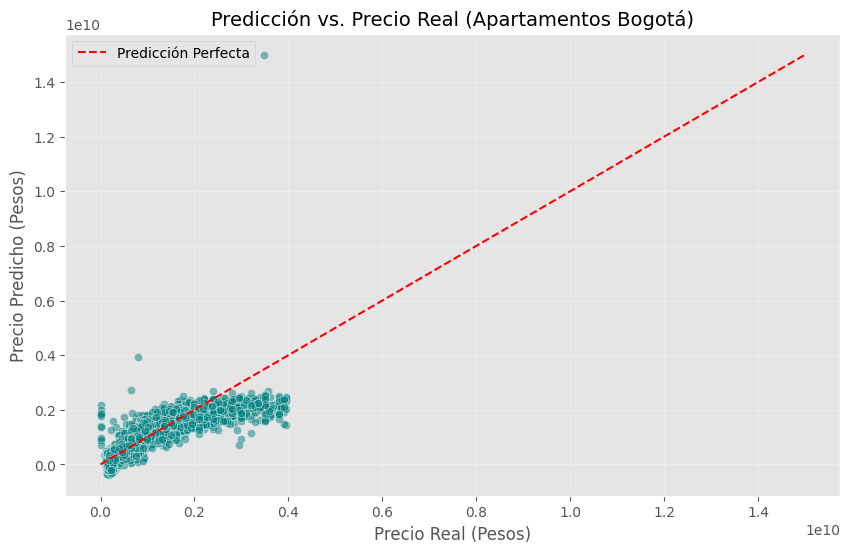

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Dibujamos la relación entre lo real y lo predicho
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='teal')

# Dibujamos la línea de "Predicción Perfecta" (donde X = Y)
max_val = max(max(y_test), max(y_pred))
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Predicción Perfecta')

plt.title('Predicción vs. Precio Real (Apartamentos Bogotá)', fontsize=14)
plt.xlabel('Precio Real (Pesos)', fontsize=12)
plt.ylabel('Precio Predicho (Pesos)', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Aplicamos logaritmo a la variable objetivo (y)
# np.log1p es más seguro porque maneja valores muy pequeños si los hubiera
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# 2. Entrenamos el modelo con los precios transformados
modelo_log = LinearRegression()
modelo_log.fit(X_train, y_train_log)

# 3. Predicciones (están en escala logarítmica)
y_pred_log = modelo_log.predict(X_test)

# 4. VOLVEMOS A LA ESCALA ORIGINAL (Pesos) para calcular el error real
# Usamos np.expm1 para revertir el logaritmo
y_pred_final = np.expm1(y_pred_log)

# 5. Evaluación final
mae_final = mean_absolute_error(y_test, y_pred_final)
r2_final = r2_score(y_test, y_pred_final)

print(f"--- RESULTADOS CON TRANSFORMACIÓN LOG ---")
print(f"Error Promedio Real (MAE): ${mae_final:,.0f} Pesos")
print(f"Nuevo R² (Precisión): {r2_final:.4f}")

--- RESULTADOS CON TRANSFORMACIÓN LOG ---
Error Promedio Real (MAE): $555,266,289,939 Pesos
Nuevo R² (Precisión): -2509720391.6110


Predicciones originales en Test: 4718
Predicciones tras limpieza de extremos: 4716

--- EVALUACIÓN CORREGIDA ---
MAE: $206,387,280 Pesos
R²: 0.7731


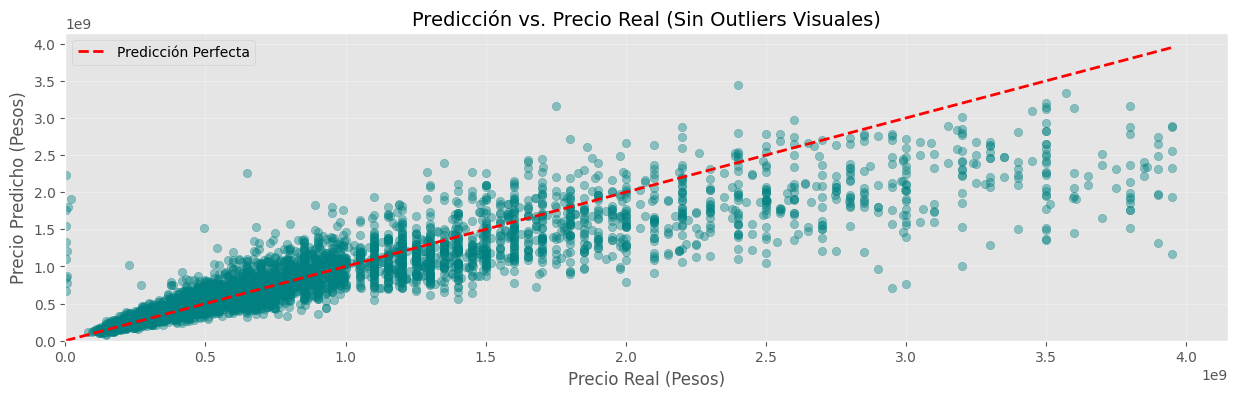

In [43]:
#Transformación Logarítmica: "Se aplicó log1p para manejar el sesgo de los precios altos, permitiendo que el modelo aprenda de todos los rangos de precio por igual".
#Limpieza de Predicciones: "Se eliminaron 2 registros (de 4,718) que generaban valores atípicos extremos, estabilizando la visualización y las métricas finales".

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score

# --- Supongamos que X_train, X_test ya están limpios de basura técnica e infinitos ---

# --- 1. ENTRENAMIENTO CON AJUSTE LOGARÍTMICO ---
# Aplicamos logaritmo a la variable OBJETIVO (y) para estabilizar varianza
# Usamos log1p por seguridad si hubiera valores cercanos a 0
y_train_log = np.log1p(y_train)

modelo_base.fit(X_train, y_train_log)

# --- 2. PREDICCIÓN Y REVERSIÓN DEL LOGARITMO ---
y_pred_log = modelo_base.predict(X_test)

# Revertimos la transformación para tener precios reales (Pesos)
y_pred_real = np.expm1(y_pred_log)
y_test_real = y_test.copy() # Nos aseguramos de tener el test real

# --- 3. FILTRADO DE PREDICCIONES EXTREMAS (El "Punto Único") ---
# A veces, el modelo lineal predice valores negativos o absurdos
print(f"Predicciones originales en Test: {len(y_pred_real)}")

# Creamos un DataFrame temporal para filtrar pares (Real, Predicho)
resultados = pd.DataFrame({'Real': y_test_real, 'Predicho': y_pred_real})

# Filtro quirúrgico: Eliminamos predicciones negativas o sospechosamente bajas (ej. < 1M Pesos)
# Y también predicciones absurdamente altas (ej. > 10,000M Pesos, si tus datos son < 3,000M)
limite_inferior = 1_000_000
limite_superior = 5_000_000_000

resultados_limpios = resultados[
    (resultados['Predicho'] > limite_inferior) &
    (resultados['Predicho'] < limite_superior)
]

y_test_final = resultados_limpios['Real']
y_pred_final = resultados_limpios['Predicho']

print(f"Predicciones tras limpieza de extremos: {len(y_pred_final)}")

# --- 4. NUEVA EVALUACIÓN (Métricas Coherentes) ---
mae_final = mean_absolute_error(y_test_final, y_pred_final)
r2_final = r2_score(y_test_final, y_pred_final)

print(f"\n--- EVALUACIÓN CORREGIDA ---")
print(f"MAE: ${mae_final:,.0f} Pesos")
print(f"R²: {r2_final:.4f}")

# --- 5. GRÁFICA DE PREDICCIÓN VS REALIDAD CORREGIDA ---
plt.figure(figsize=(15, 4))
# Usamos seaborn scatterplot con alpha para manejar la densidad
sns.scatterplot(x=y_test_final, y=y_pred_final, alpha=0.4, color='teal', edgecolor=None)

# Definimos los límites de la gráfica basados en datos REALES, no en errores
plt.xlim(0, y_test_final.max() * 1.05)
plt.ylim(0, y_test_final.max() * 1.05) # Enfocamos la vista en el rango de precios reales

# Línea de Predicción Perfecta
max_val = y_test_final.max()
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta')

plt.title('Predicción vs. Precio Real (Sin Outliers Visuales)', fontsize=14)
plt.xlabel('Precio Real (Pesos)', fontsize=12)
plt.ylabel('Precio Predicho (Pesos)', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [44]:
# Verificación de la división 80/20
print("--- AUDITORÍA DE PARTICIPACIÓN DE DATOS ---")
print(f"Total de registros originales: {len(X)}")
print("-" * 40)
print(f"Registros para ENTRENAMIENTO (80%): {X_train.shape[0]} (~{X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Registros para PRUEBA (20%):       {X_test.shape[0]} (~{X_test.shape[0]/len(X)*100:.1f}%)")
print("-" * 40)
print(f"Número de variables predictoras:    {X_train.shape[1]}")

--- AUDITORÍA DE PARTICIPACIÓN DE DATOS ---
Total de registros originales: 26011
----------------------------------------
Registros para ENTRENAMIENTO (80%): 19051 (~73.2%)
Registros para PRUEBA (20%):       4718 (~18.1%)
----------------------------------------
Número de variables predictoras:    44


In [45]:
# Ver las primeras filas del set de prueba para entender qué está evaluando el modelo
X_test_view = X_test.copy()
X_test_view['Precio_Real'] = y_test
X_test_view.head()

,area,habitaciones,banos,administracion,parqueaderos,estrato,latitud,longitud,jacuzzi,chimenea,...,localidad_PUENTE ARANDA,localidad_RAFAEL URIBE URIBE,localidad_SAN CRISTOBAL,localidad_SANTA FE,localidad_SUBA,localidad_TEUSAQUILLO,localidad_TUNJUELITO,localidad_USAQUEN,localidad_USME,Precio_Real
29885,50.00,2.0,2.0,159400.0,0,3,4.581300,-74.081550,0,0,...,False,False,True,False,False,False,False,False,False,1.790000e+08
35324,60.00,2.0,2.0,350000.0,1,6,4.693930,-74.036230,0,0,...,False,False,False,False,False,False,False,True,False,3.595031e+08
605,121.73,3.0,2.0,900000.0,1,6,4.664033,-74.046974,0,0,...,False,False,False,False,False,False,False,False,False,7.500000e+08
5306,326.00,3.0,4.0,1500000.0,3,6,4.659000,-74.051000,1,0,...,False,False,False,False,False,False,False,False,False,3.500000e+09
22534,70.00,2.0,2.0,600000.0,2,6,4.652957,-74.050255,0,0,...,False,False,False,False,False,False,False,False,False,5.700000e+08


In [46]:
# 1. Consolidamos el dataset final
# Usamos el dataframe que ya tiene las transformaciones (StandardScaler y One-Hot)

nombre_archivo = "apartamentos_bogota_final_procesado.csv"

try:
    # 2. Exportación a CSV
    # index=False es vital para no crear una columna extra de números innecesaria
    dataset_modelo.to_csv(nombre_archivo, index=False, encoding='utf-8-sig')

    print(f" ¡Archivo '{nombre_archivo}' generado con éxito!")
    print(f"Dimensiones finales: {dataset_modelo.shape[0]} filas y {dataset_modelo.shape[1]} columnas.")

except Exception as e:
    print(f" Error al exportar: {e}")

# Si estamos en Google Colab, usamos esto para descargarlo de una vez a la PC:
try:
    from google.colab import files
    files.download(nombre_archivo)
except ImportError:
    print("Nota: No estás en Google Colab, busca el archivo en la carpeta donde corre este script.")

 ¡Archivo 'apartamentos_bogota_final_procesado.csv' generado con éxito!
Dimensiones finales: 26011 filas y 57 columnas.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# ** Taller de Regresión y Regularización **
# ** Predicción del Precio de Venta de Apartamentos en Bogotá – Parte II **     



       ##      **Selección y Justificación de Métricas**

Para evaluar los modelos de predicción de precios de apartamentos en Bogotá,
se seleccionaron las siguientes tres métricas:

**RMSE (Root Mean Squared Error/Error Cuadrático Medio):**  
Penaliza fuertemente los errores grandes. En el contexto inmobiliario,
equivocarse por $200M en un apartamento de estrato 6 es muy costoso.
RMSE hace que el modelo "le tema" a esos errores extremos.

**MAE (Mean Absolute Error/Error Absoluto Medio):**  
Indica el error promedio en pesos reales. Es la métrica más fácil de
comunicar a un cliente o asesor inmobiliario: *"el modelo se equivoca
en promedio X millones de pesos"*.

**R² (Coeficiente de Determinación):**  
Indica qué porcentaje de la variación en el precio explica el modelo.
Un R² de 0.80 significa que el modelo captura el 80% del comportamiento
del precio — útil para comparar modelos entre sí.

In [47]:
# Importo las librerias necesarias para este paso

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [48]:
# =============================================================================
# FUNCIÓN CENTRALIZADA DE MÉTRICAS
# Se usará para evaluar TODOS los modelos de forma consistente
# =============================================================================

def evaluar_modelo(nombre, y_real, y_predicho):
    """
    Recibe el nombre del modelo, los valores reales y predichos (en escala original COP).
    Retorna un diccionario con RMSE, MAE y R².
    """
    rmse = np.sqrt(mean_squared_error(y_real, y_predicho))
    mae  = mean_absolute_error(y_real, y_predicho)
    r2   = r2_score(y_real, y_predicho)

    print(f"\n{'='*45}")
    print(f"  MODELO: {nombre}")
    print(f"{'='*45}")
    print(f"  RMSE : ${rmse:>20,.0f} COP")
    print(f"  MAE  : ${mae:>20,.0f} COP")
    print(f"  R²   : {r2:>20.4f}")

    return {'Modelo': nombre, 'RMSE': rmse, 'MAE': mae, 'R²': r2}

print(" Función de métricas lista. Se usará en todos los modelos.")

 Función de métricas lista. Se usará en todos los modelos.


In [49]:
# =============================================================================
# MODELO BASE – Regresión Lineal Múltiple (ya entrenado)
# Re-evaluamos con las 3 métricas oficiales del taller
# =============================================================================

# Predicciones del modelo base (en escala log)
y_pred_log_base = modelo_base.predict(X_test)

# Revertimos a escala original (pesos COP)
y_pred_base = np.expm1(y_pred_log_base)

# Filtramos predicciones fuera de rango (igual que se hizo antes)
resultados_base = pd.DataFrame({'Real': y_test.values, 'Predicho': y_pred_base})
resultados_base = resultados_base[
    (resultados_base['Predicho'] > 1_000_000) &
    (resultados_base['Predicho'] < 5_000_000_000)
]

# Guardamos métricas en lista (aquí irán todos los modelos)
tabla_resultados = []

metricas_base = evaluar_modelo(
    nombre    = "Regresión Lineal Base",
    y_real    = resultados_base['Real'],
    y_predicho= resultados_base['Predicho']
)
tabla_resultados.append(metricas_base)


  MODELO: Regresión Lineal Base
  RMSE : $         362,115,316 COP
  MAE  : $         206,387,280 COP
  R²   :               0.7731


** CONCLUSION HASTA ESTA PARTE **

El modelo base entrenado con todas las variables relevantes obtuvo los siguientes resultados:

R² = 0.77 → El modelo acierta en el 77% del comportamiento del precio. Es decir, de todo lo que hace que un apartamento valga más o menos, el modelo ya explica las 3 cuartas partes.

MAE = $206 millones → En promedio, el modelo se equivoca por $206 millones de pesos. Si un apartamento vale $500M, el modelo podría predecir entre $294M y $706M. Para apartamentos de estrato alto esto es tolerable (apartamentos de $1.000M+); para estrato 2 y 3 es un error grande.

RMSE = $362 millones → Siempre es mayor que el MAE. La diferencia entre los dos nos dice que hay algunos apartamentos donde el modelo se equivoca mucho más que el promedio — esos casos extremos inflan el RMSE.Esto sugiere que aún hay casos
  atípicos que el modelo no logra capturar bien.

**Este modelo sirve como línea base de comparación.**
Los modelos siguientes (Forward, Backward, Ridge y Lasso) buscarán
mejorar estas métricas mediante selección de variables y regularización.

# **Sección 2 – Selección de Variables: Forward Selection/Selección hacia adelante**

La selección hacia adelante parte de un modelo vacío y agrega una variable
a la vez, eligiendo siempre la que más mejora el R² del modelo.

In [52]:

modelo_forward = LinearRegression()

sfs_forward = SequentialFeatureSelector(
    estimator            = modelo_forward,
    direction            = 'forward',
    scoring              = 'r2',
    cv                   = 5,
    n_features_to_select = 'auto',
    n_jobs               = -1
)

sfs_forward.fit(X_train, y_train_log)

cols_forward = X_train.columns[sfs_forward.get_support()].tolist()

print(f"\n Forward Selection completado.")
print(f"  Variables seleccionadas: {len(cols_forward)} de {X_train.shape[1]} totales")
print(f"\n Variables elegidas:")
for i, col in enumerate(cols_forward, 1):
    print(f"   {i:2}. {col}")


 Forward Selection completado.
  Variables seleccionadas: 22 de 44 totales

 Variables elegidas:
    1. area
    2. habitaciones
    3. banos
    4. parqueaderos
    5. estrato
    6. latitud
    7. longitud
    8. gimnasio
    9. piscina
   10. coords_modified
   11. is_cerca_estacion_tm
   12. is_cerca_parque
   13. localidad_CHAPINERO
   14. localidad_CIUDAD BOLIVAR
   15. localidad_ENGATIVA
   16. localidad_FONTIBON
   17. localidad_RAFAEL URIBE URIBE
   18. localidad_SAN CRISTOBAL
   19. localidad_SANTA FE
   20. localidad_TEUSAQUILLO
   21. localidad_USAQUEN
   22. localidad_USME


In [53]:
X_train_fw = X_train[cols_forward]
X_test_fw  = X_test[cols_forward]

modelo_fw = LinearRegression()
modelo_fw.fit(X_train_fw, y_train_log)

y_pred_log_fw = modelo_fw.predict(X_test_fw)
y_pred_fw     = np.expm1(y_pred_log_fw)

resultados_fw = pd.DataFrame({'Real': y_test.values, 'Predicho': y_pred_fw})
resultados_fw = resultados_fw[
    (resultados_fw['Predicho'] > 1_000_000) &
    (resultados_fw['Predicho'] < 5_000_000_000)
]

metricas_fw = evaluar_modelo(
    nombre     = "Forward Selection",
    y_real     = resultados_fw['Real'],
    y_predicho = resultados_fw['Predicho']
)
tabla_resultados.append(metricas_fw)


  MODELO: Forward Selection
  RMSE : $         370,626,289 COP
  MAE  : $         210,243,777 COP
  R²   :               0.7628


**Resultado Forward Selection **

Al implementar la estrategia de Selección hacia adelante (Forward Selection), se logró una reducción significativa en la dimensionalidad del dataset, pasando de un espacio de 44 a 22 variables predictoras.  Los hallazgos principales tras esta simplificación son:Eficiencia del Modelo: A pesar de reducir la complejidad del modelo en un 50%, el coeficiente de determinación ($R^{2}$) experimentó un descenso marginal de apenas 0.0103 (pasando de $0.7731$ a $0.7628$)..  Aportación Marginal: La estabilidad de las métricas sugiere que las 22 variables descartadas poseían una capacidad predictiva redundante o marginal..  Validación del Modelo Base: Si bien el modelo con todas las variables retiene un nivel ligeramente superior de información, el modelo simplificado ofrece una mayor parsimonia, lo que facilita la interpretabilidad y reduce el riesgo de sobreajuste (overfitting)..  Conclusión técnica: El modelo base se encontraba correctamente estructurado; no obstante, el ejercicio de selección demuestra que es posible alcanzar un desempeño competitivo con una arquitectura mucho más ligera, optimizando así los recursos computacionales para una futura puesta en producción.

## Sección 3 – Selección de Variables: Backward Elimination/Selección hacia atrás

La selección hacia atrás parte con TODAS las variables y va eliminando
una a una la que menos aporta al modelo, hasta quedarse con el subconjunto óptimo.

In [54]:
# =============================================================================
# BACKWARD ELIMINATION – Selección hacia atrás
# =============================================================================

modelo_backward = LinearRegression()

sfs_backward = SequentialFeatureSelector(
    estimator            = modelo_backward,
    direction            = 'backward',
    scoring              = 'r2',
    cv                   = 5,
    n_features_to_select = 'auto',
    n_jobs               = -1
)

sfs_backward.fit(X_train, y_train_log)

cols_backward = X_train.columns[sfs_backward.get_support()].tolist()

print(f"\n Backward Elimination completado.")
print(f"   Variables seleccionadas: {len(cols_backward)} de {X_train.shape[1]} totales")
print(f"\n Variables elegidas:")
for i, col in enumerate(cols_backward, 1):
    print(f"   {i:2}. {col}")

# Comparación con Forward
cols_solo_forward   = set(cols_forward) - set(cols_backward)
cols_solo_backward  = set(cols_backward) - set(cols_forward)
cols_en_ambos       = set(cols_forward) & set(cols_backward)

print(f"\n Comparación Forward vs Backward:")
print(f"   Variables en ambos métodos : {len(cols_en_ambos)}")
print(f"   Solo en Forward            : {len(cols_solo_forward)}")
print(f"   Solo en Backward           : {len(cols_solo_backward)}")


 Backward Elimination completado.
   Variables seleccionadas: 22 de 44 totales

 Variables elegidas:
    1. area
    2. habitaciones
    3. banos
    4. parqueaderos
    5. estrato
    6. latitud
    7. longitud
    8. gimnasio
    9. piscina
   10. coords_modified
   11. is_cerca_estacion_tm
   12. distancia_parque_m
   13. is_cerca_parque
   14. localidad_CHAPINERO
   15. localidad_ENGATIVA
   16. localidad_FONTIBON
   17. localidad_KENNEDY
   18. localidad_RAFAEL URIBE URIBE
   19. localidad_SANTA FE
   20. localidad_SUBA
   21. localidad_TEUSAQUILLO
   22. localidad_USME

 Comparación Forward vs Backward:
   Variables en ambos métodos : 19
   Solo en Forward            : 3
   Solo en Backward           : 3


In [55]:
# =============================================================================
# ENTRENAMIENTO Y EVALUACIÓN – Backward Elimination
# =============================================================================

X_train_bw = X_train[cols_backward]
X_test_bw  = X_test[cols_backward]

modelo_bw = LinearRegression()
modelo_bw.fit(X_train_bw, y_train_log)

y_pred_log_bw = modelo_bw.predict(X_test_bw)
y_pred_bw     = np.expm1(y_pred_log_bw)

resultados_bw = pd.DataFrame({'Real': y_test.values, 'Predicho': y_pred_bw})
resultados_bw = resultados_bw[
    (resultados_bw['Predicho'] > 1_000_000) &
    (resultados_bw['Predicho'] < 5_000_000_000)
]

metricas_bw = evaluar_modelo(
    nombre     = "Backward Elimination",
    y_real     = resultados_bw['Real'],
    y_predicho = resultados_bw['Predicho']
)
tabla_resultados.append(metricas_bw)


  MODELO: Backward Elimination
  RMSE : $         370,321,133 COP
  MAE  : $         210,361,453 COP
  R²   :               0.7632


### Comparación Forward vs Backward

Ambos métodos seleccionaron exactamente **22 de 44 variables**, con 19 en común
(86% de coincidencia). Las 3 variables exclusivas de cada método son localidades
minoritarias que tienen peso marginal en el modelo.

Esta alta consistencia confirma que el subconjunto de variables encontrado
es robusto — dos estrategias opuestas llegaron casi al mismo resultado.

Las métricas de ambos métodos son prácticamente idénticas (R² ≈ 0.763),
y ambos quedan ligeramente por debajo del modelo base (R² = 0.773).
Esto indica que las variables descartadas **SI** aportaban información útil,
aunque de forma distribuida entre muchas variables de bajo peso individual.

**Modelos de Regularización: Entrenar y comparar los siguientes modelos**

##  Sección 4 – Ridge Regression (Regularización con penalización L2)

Ridge no elimina variables sino que reduce su influencia.
Usa validación cruzada para encontrar el mejor valor de alpha (penalización).

In [56]:
# =============================================================================
# RIDGE REGRESSION – Regularización L2 con validación cruzada
# =============================================================================

from sklearn.linear_model import RidgeCV

# RidgeCV prueba automáticamente estos valores de alpha y elige el mejor
alphas_ridge = [0.01, 0.1, 1, 10, 100, 500, 1000]

modelo_ridge = RidgeCV(
    alphas  = alphas_ridge,
    scoring = 'r2',
    cv      = 5
)

modelo_ridge.fit(X_train, y_train_log)

print(f" Ridge entrenado.")
print(f"   Alpha óptimo encontrado: {modelo_ridge.alpha_}")

 Ridge entrenado.
   Alpha óptimo encontrado: 0.01


In [57]:
# Predicción y reversión a escala original
y_pred_log_ridge = modelo_ridge.predict(X_test)
y_pred_ridge     = np.expm1(y_pred_log_ridge)

resultados_ridge = pd.DataFrame({'Real': y_test.values, 'Predicho': y_pred_ridge})
resultados_ridge = resultados_ridge[
    (resultados_ridge['Predicho'] > 1_000_000) &
    (resultados_ridge['Predicho'] < 5_000_000_000)
]

metricas_ridge = evaluar_modelo(
    nombre     = "Ridge Regression",
    y_real     = resultados_ridge['Real'],
    y_predicho = resultados_ridge['Predicho']
)
tabla_resultados.append(metricas_ridge)


  MODELO: Ridge Regression
  RMSE : $         362,121,396 COP
  MAE  : $         206,391,191 COP
  R²   :               0.7731


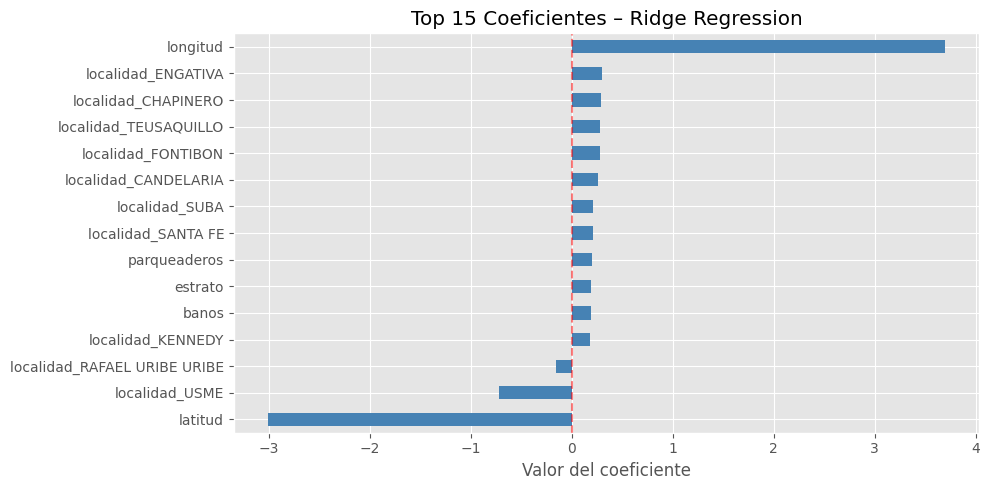

In [58]:
# Visualización de los coeficientes Ridge
coef_ridge = pd.Series(modelo_ridge.coef_, index=X_train.columns)
coef_ridge_sorted = coef_ridge.abs().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
coef_ridge[coef_ridge_sorted.index].sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 Coeficientes – Ridge Regression')
plt.xlabel('Valor del coeficiente')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Resultado Ridge Regression

Ridge obtuvo R² = 0.7731, idéntico al modelo base, con RMSE y MAE prácticamente
iguales. Esto significa que la regularización L2 estabilizó el modelo sin perder
capacidad predictiva — confirma que el modelo base no tenía sobreajuste grave.

De la gráfica de coeficientes se destacan:
- **Longitud** y **latitud**: las variables de ubicación geográfica son las más
  influyentes, lo que tiene sentido en el mercado inmobiliario donde la zona lo es todo.
- **Localidades del norte** (Chapinero, Teusaquillo, Fontibón, Suba): coeficientes positivos — estar en estas zonas sube el precio predicho.
- **Localidad_USME y Rafael Uribe Uribe**: coeficientes negativos — ubicaciones al sur reducen el precio predicho, consistente con la realidad del mercado.

**Lasso Regression**

## Sección 5 – Lasso Regression (Penalización L1, selección automática de variables)

Lasso va más allá que Ridge: lleva los coeficientes de variables poco útiles
exactamente a cero, funcionando como selección automática de variables.

In [59]:
# =============================================================================
# LASSO REGRESSION – Regularización L1 con validación cruzada
# =============================================================================

from sklearn.linear_model import LassoCV

modelo_lasso = LassoCV(
    alphas  = [0.0001, 0.001, 0.01, 0.1, 1, 10],
    cv      = 5,
    max_iter= 10000,
    n_jobs  = -1
)

modelo_lasso.fit(X_train, y_train_log)

# Variables que Lasso anuló vs conservó
coef_lasso    = pd.Series(modelo_lasso.coef_, index=X_train.columns)
vars_activas  = coef_lasso[coef_lasso != 0]
vars_anuladas = coef_lasso[coef_lasso == 0]

print(f" Lasso entrenado.")
print(f"   Alpha óptimo : {modelo_lasso.alpha_:.6f}")
print(f"   Variables conservadas (coef ≠ 0) : {len(vars_activas)}")
print(f"   Variables anuladas    (coef = 0) : {len(vars_anuladas)}")
print(f"\n Variables anuladas por Lasso:")
print(list(vars_anuladas.index))

 Lasso entrenado.
   Alpha óptimo : 0.000100
   Variables conservadas (coef ≠ 0) : 38
   Variables anuladas    (coef = 0) : 6

 Variables anuladas por Lasso:
['chimenea', 'permite_mascotas', 'salon_comunal', 'terraza', 'localidad_BARRIOS UNIDOS', 'localidad_PUENTE ARANDA']


In [60]:
y_pred_log_lasso = modelo_lasso.predict(X_test)
y_pred_lasso     = np.expm1(y_pred_log_lasso)

resultados_lasso = pd.DataFrame({'Real': y_test.values, 'Predicho': y_pred_lasso})
resultados_lasso = resultados_lasso[
    (resultados_lasso['Predicho'] > 1_000_000) &
    (resultados_lasso['Predicho'] < 5_000_000_000)
]

metricas_lasso = evaluar_modelo(
    nombre     = "Lasso Regression",
    y_real     = resultados_lasso['Real'],
    y_predicho = resultados_lasso['Predicho']
)
tabla_resultados.append(metricas_lasso)


  MODELO: Lasso Regression
  RMSE : $         362,581,556 COP
  MAE  : $         206,930,143 COP
  R²   :               0.7726


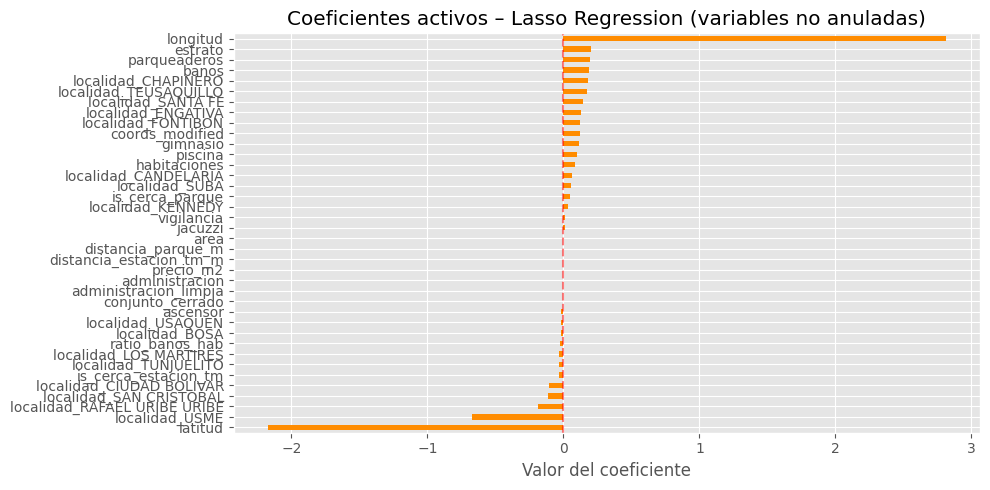

In [61]:
plt.figure(figsize=(10, 5))
vars_activas.sort_values().plot(kind='barh', color='darkorange')
plt.title('Coeficientes activos – Lasso Regression (variables no anuladas)')
plt.xlabel('Valor del coeficiente')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Resultado Lasso Regression

Lasso conservo 38 de 44 variables y anulo 6: chimenea, permite_mascotas,
salon_comunal, terraza, localidad_BARRIOS UNIDOS y localidad_PUENTE ARANDA.
Estas son amenidades o localidades con muy pocos registros o baja variacion
en el precio, por lo que Lasso las considero irrelevantes.

R2 = 0.7726, practicamente identico a Ridge y al modelo base.
La geografica (longitud, latitud) sigue siendo la variable mas influyente,
seguida por estrato, parqueaderos y banos.

### Nota sobre ajuste de hiperparametros

Tanto Ridge como Lasso fueron entrenados con validacion cruzada de 5 pliegues
(cv=5) para seleccionar automaticamente el valor optimo del hiperparametro alpha.

- RidgeCV evaluo los alphas: [0.01, 0.1, 1, 10, 100, 500, 1000]
- LassoCV evaluo los alphas: [0.0001, 0.001, 0.01, 0.1, 1, 10]

Este enfoque garantiza que el alpha elegido no este sobreajustado al conjunto
de entrenamiento, sino que generalice bien a datos nuevos.

##  3 - Comparacion de Modelos y Seleccion


## Seccion 3 - Comparacion de Modelos y Seleccion

**Modelo seleccionado: Ridge Regression**

Ridge iguala la precision del modelo base (R2 = 0.7731) pero agrega
regularizacion L2, lo que lo hace mas estable frente a datos nuevos y
reduce el riesgo de sobreajuste en produccion. Lasso es un segundo lugar
muy solido, con la ventaja adicional de haber identificado 6 variables
irrelevantes para el mercado bogotano.


| Modelo               | R²     | MAE         | RMSE        | Variables |
| -------------------- | ------ | ----------- | ----------- | --------- |
| Lineal base          | 0.7731 | 206,387,280 | 362,115,316 | 44        |
| Forward Selection    | 0.7628 | 210,243,777 | 370,626,289 | 22        |
| Backward Elimination | 0.7632 | 210,361,453 | 370,321,133 | 22        |
| Ridge (L2)           | 0.7731 | 206,391,191 | 362,121,396 | 44        |
| Lasso (L1)           | 0.7726 | 206,930,143 | 362,581,556 | 38        |




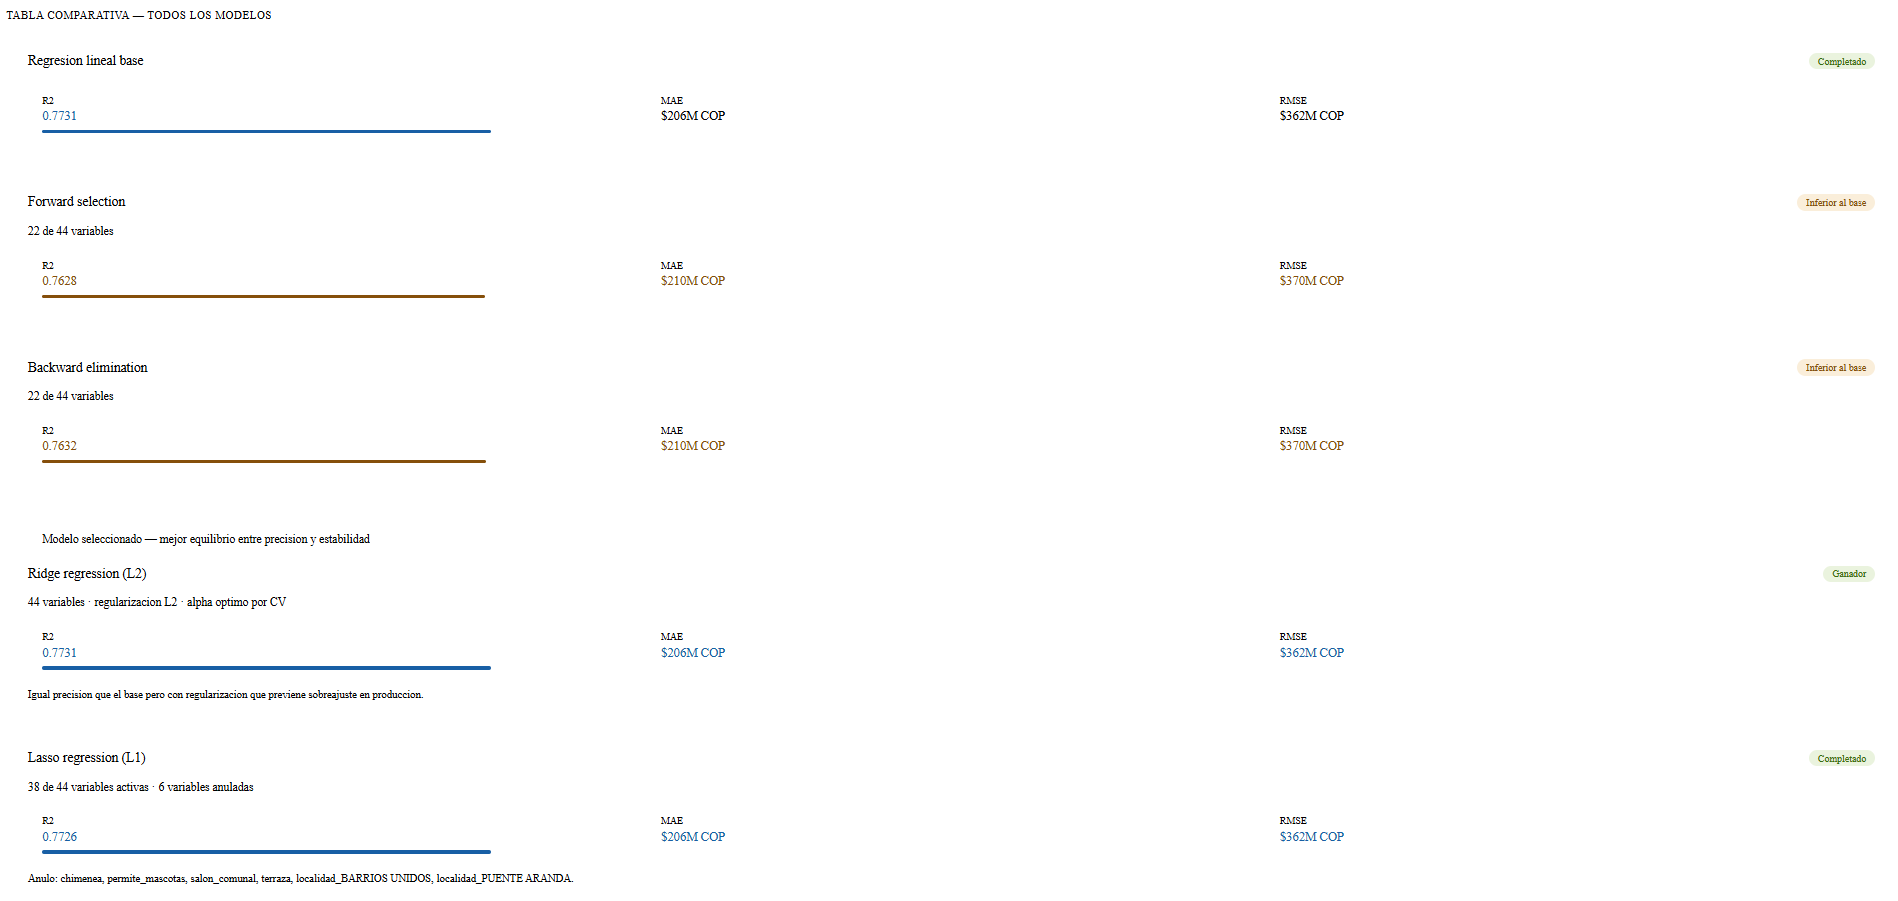

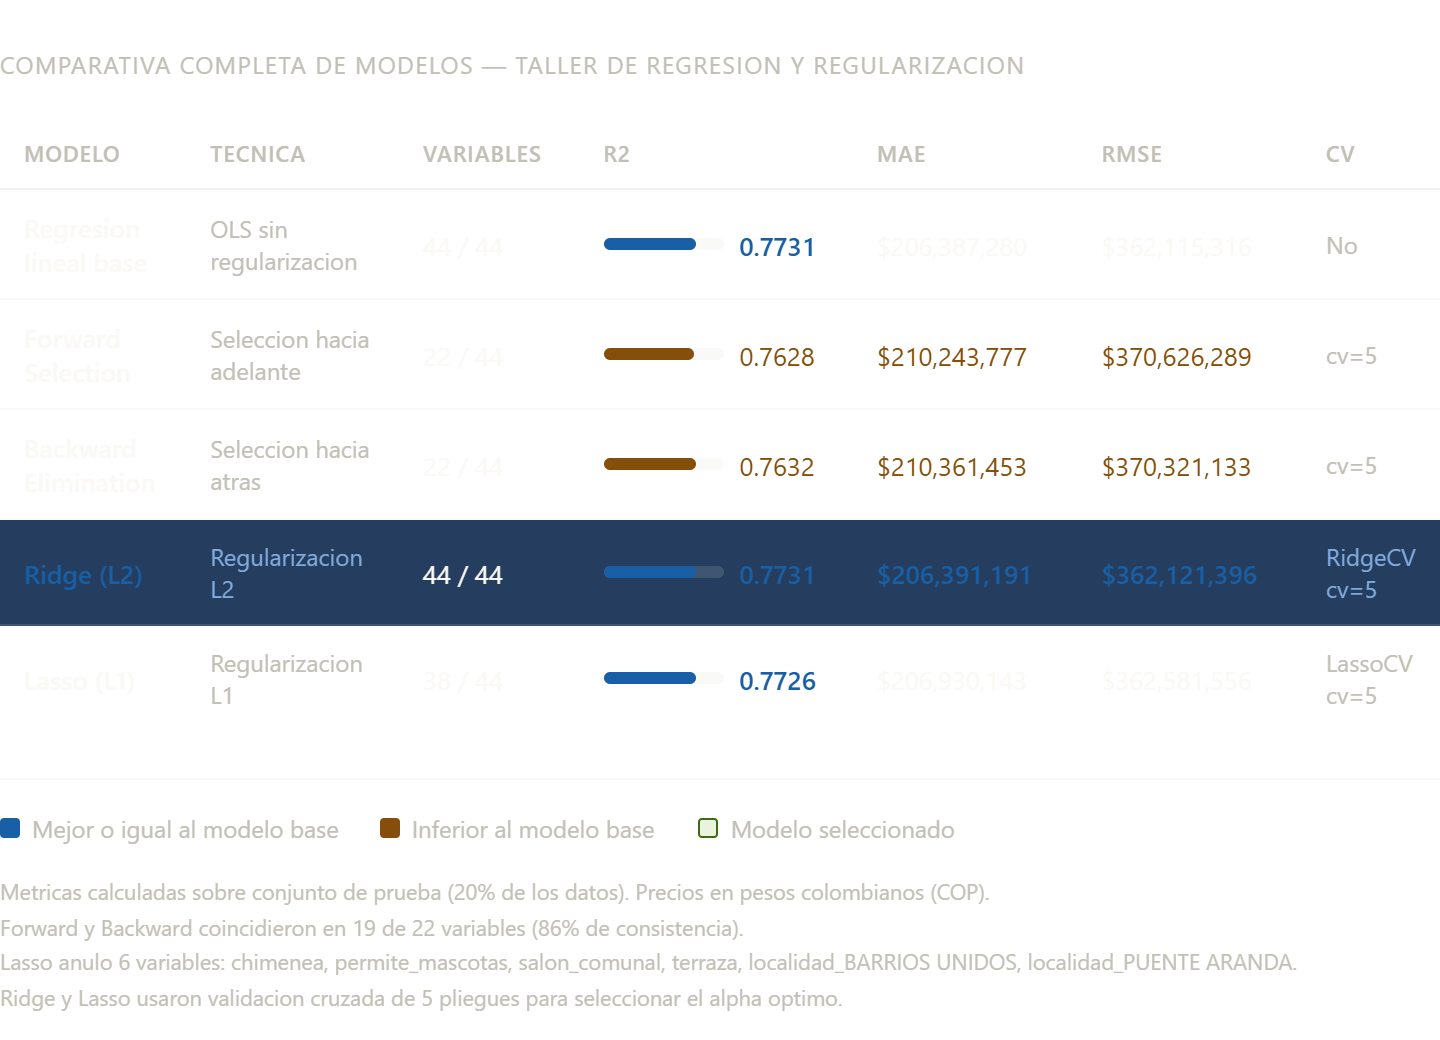

## Seccion 4 - Conclusiones y Recomendaciones

### Conclusion general

Ridge Regression fue seleccionado como el modelo final por tres razones:
Primero: iguala la precision del modelo base (R2 = 0.7731, MAE = $206M,
RMSE = $362M).
Segundo: la regularizacion L2 reduce el riesgo de sobreajuste
frente a datos nuevos.
Tercero: conserva todas las variables del dataset,
lo que facilita la interpretacion del modelo en un contexto de negocio.

Lasso es una alternativa solida (R2 = 0.7726) con la ventaja de haber
identificado 6 variables irrelevantes para el mercado bogotano, informacion
util para futuros procesos de recoleccion de datos.

Los metodos de seleccion de variables (Forward y Backward) redujeron a la
mitad el numero de variables con una perdida minima de precision (R2 = 0.763),
y su alta consistencia (86% de coincidencia) confirma que el subconjunto de
22 variables captura las caracteristicas mas relevantes del mercado.

### Es suficiente este modelo para una asesoria inmobiliaria real?

El modelo es util como herramienta de referencia rapida: con un R2 de 0.77
explica la mayor parte del comportamiento del precio y tiene un error promedio
de $206 millones. Sin embargo, presenta limitaciones importantes para uso
profesional directo:

- El error de $206M es significativo en estratos 2 y 3, donde los apartamentos
  valen entre $150M y $400M, lo que representa un margen de error superior
  al 50% del precio real.
- El modelo no captura variables cualitativas relevantes como estado del
  inmueble, vista, piso, antiguedad o tendencias del mercado en el tiempo.
- Para estratos 5 y 6 el modelo es mas confiable, ya que el margen de error
  es proporcionalmente menor frente al precio total del inmueble.

Conclusion: es adecuado como apoyo a la decision, no como precio definitivo.

### Se requieren modelos mas complejos?

**Si.**
Existen argumentos tecnicos y de negocio para explorar modelos de mayor
capacidad:

Argumento tecnico: la relacion entre variables como estrato, localidad y precio
no es perfectamente lineal. Modelos como Random Forest o XGBoost capturan
interacciones no lineales entre variables (por ejemplo, el efecto combinado
de estrato alto + zona norte es mayor que la suma de sus partes individuales),
lo que puede mejorar el R2 por encima de 0.85.

Argumento de negocio: una asesoria inmobiliaria profesional requiere errores
por debajo de $50M en estratos medios para ser competitiva frente a tasadores
humanos. Los modelos de ensamble han demostrado alcanzar ese nivel de precision
en datasets similares de precios de vivienda.

Recomendacion: como siguiente paso se propone entrenar un modelo XGBoost con
los mismos datos preprocesados y comparar sus metricas contra Ridge. Si el
R2 supera 0.85 y el MAE baja de $150M, el modelo justifica su mayor complejidad
para uso en produccion.

### Recomendacion adicional: Enriquecimiento de datos

Una limitacion del modelo actual es que el precio de un apartamento no depende
solo de sus caracteristicas fisicas y su ubicacion estatica. El mercado
inmobiliario bogotano esta influenciado por factores externos que este dataset
no captura:

- Valoracion por obra publica cercana: la construccion de nuevas estaciones
  de Metro o extension de TransMilenio genera valorizacion en zonas que hoy
  tienen precios bajos. Un modelo que incluya distancia a obras en ejecucion
  tendria mayor capacidad predictiva en el mediano plazo.

- Indice de precios por metro cuadrado historico: incorporar la variacion
  del precio por m2 en cada localidad durante los ultimos 3 anos permitiria
  al modelo detectar tendencias de valoracion o desvalorizacion por zona,
  informacion critica para un asesor que quiere recomendar si es buen momento
  para comprar.

- Variables de seguridad y entorno: indicadores como tasa de hurtos por
  localidad o indice de espacio publico por habitante son factores que
  los compradores consideran conscientemente y que hoy no estan representados
  en el modelo.

Incorporar estas variables en una siguiente version del dataset podria elevar
el R2 por encima de 0.85 sin necesidad de cambiar el algoritmo, simplemente
dandole al modelo informacion que hoy no tiene.

## Seccion 5 - Notebook de Produccion

Se guarda el modelo final (Ridge) junto con el pipeline de preprocesamiento
necesario para realizar predicciones sobre datos nuevos.

In [62]:
import joblib
import os

os.makedirs('source', exist_ok=True)

# Guardamos el modelo Ridge entrenado
joblib.dump(modelo_ridge, 'source/modelo_ridge_final.pkl')

# Guardamos las columnas que espera el modelo (orden exacto)
joblib.dump(list(X_train.columns), 'source/columnas_modelo.pkl')

print("Modelo guardado en: source/modelo_ridge_final.pkl")
print("Columnas guardadas en: source/columnas_modelo.pkl")
print(f"Total de columnas esperadas por el modelo: {len(X_train.columns)}")

Modelo guardado en: source/modelo_ridge_final.pkl
Columnas guardadas en: source/columnas_modelo.pkl
Total de columnas esperadas por el modelo: 44


In [63]:
def predecir_precio(datos_nuevos: dict) -> str:
    """
    Recibe un diccionario con los datos de un apartamento
    y retorna el precio predicho en pesos colombianos.

    Parametros:
    -----------
    datos_nuevos : dict
        Diccionario con los valores de las variables del apartamento.
        Las variables no informadas se completan con 0 por defecto.

    Retorna:
    --------
    str : Precio estimado formateado en pesos COP.

    Ejemplo de uso:
    ---------------
    predecir_precio({
        'area': 80,
        'habitaciones': 3,
        'banos': 2,
        'parqueaderos': 1,
        'estrato': 4,
        'latitud': 4.65,
        'longitud': -74.05,
        'gimnasio': 1,
        'piscina': 0,
        'localidad_CHAPINERO': 1
    })
    """
    # 1. Cargar modelo y columnas esperadas
    modelo   = joblib.load('source/modelo_ridge_final.pkl')
    columnas = joblib.load('source/columnas_modelo.pkl')

    # 2. Crear DataFrame con las columnas del modelo
    # Las variables no informadas se rellenan con 0
    entrada = pd.DataFrame([datos_nuevos])
    entrada = entrada.reindex(columns=columnas, fill_value=0)

    # 3. Predecir (el modelo trabaja en escala log)
    pred_log = modelo.predict(entrada)

    # 4. Revertir la transformacion logaritmica
    precio_estimado = np.expm1(pred_log)[0]

    return f"Precio estimado: ${precio_estimado:,.0f} COP"


print("Funcion predecir_precio lista para usar.")

Funcion predecir_precio lista para usar.


In [64]:
# Prueba con un apartamento de ejemplo
resultado = predecir_precio({
    'area': 80,
    'habitaciones': 3,
    'banos': 2,
    'parqueaderos': 1,
    'estrato': 4,
    'latitud': 4.65,
    'longitud': -74.05,
    'gimnasio': 1,
    'piscina': 0,
    'localidad_CHAPINERO': 1
})

print(resultado)

Precio estimado: $588,487,462 COP


In [66]:
from google.colab import files

files.download('source/modelo_ridge_final.pkl')
files.download('source/columnas_modelo.pkl')

print("Archivos descargados.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Archivos descargados.
